In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_data():
    return pd.read_csv("drug_discovery_virtual_screening.csv")

df = read_data()

In [25]:
def show_head(df):
    return df.head(10)

show_head(df)

,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0
5,CID_00005,PID_201,426.586304,3.819941,2,1,5,77.316388,2.111839,1243,4.613013,NaN,18.652637,0.343191,17.621434,6.299797,0
6,CID_00006,PID_313,607.921282,3.501808,1,11,4,80.242292,3.580151,657,5.282395,0.652720,15.612028,0.925299,18.497934,6.233967,0
7,CID_00007,PID_477,526.743473,2.274367,0,3,5,124.787809,2.783815,839,6.382959,0.498718,12.237890,0.627823,14.517192,5.938336,0
8,CID_00008,PID_249,403.052561,4.488869,0,2,5,93.118700,4.035318,1308,4.552730,0.617141,17.566131,0.308144,20.436604,6.596270,0
9,CID_00009,PID_164,504.256004,4.906355,1,7,6,89.566700,0.903160,775,5.227529,0.549107,15.890644,0.650653,25.648116,7.009716,1


In [4]:
def values_check(df):
    return df.isnull().sum(),df.duplicated().sum(),df.dtypes

missing_values,duplicate,data_value = values_check(df)

In [5]:
print(missing_values)
print("Duplicates values",duplicate)
print(data_value)

compound_id             0
protein_id              0
molecular_weight        0
logp                   60
h_bond_donors           0
h_bond_acceptors        0
rotatable_bonds         0
polar_surface_area     60
compound_clogp          0
protein_length          0
protein_pi              0
hydrophobicity         60
binding_site_size       0
mw_ratio                0
logp_pi_interaction     0
binding_affinity        0
active                  0
dtype: int64
Duplicates values 0
compound_id             object
protein_id              object
molecular_weight       float64
logp                   float64
h_bond_donors            int64
h_bond_acceptors         int64
rotatable_bonds          int64
polar_surface_area     float64
compound_clogp         float64
protein_length           int64
protein_pi             float64
hydrophobicity         float64
binding_site_size      float64
mw_ratio               float64
logp_pi_interaction    float64
binding_affinity       float64
active                   int6

In [6]:
df.columns

Index(['compound_id', 'protein_id', 'molecular_weight', 'logp',
       'h_bond_donors', 'h_bond_acceptors', 'rotatable_bonds',
       'polar_surface_area', 'compound_clogp', 'protein_length', 'protein_pi',
       'hydrophobicity', 'binding_site_size', 'mw_ratio',
       'logp_pi_interaction', 'binding_affinity', 'active'],
      dtype='object')

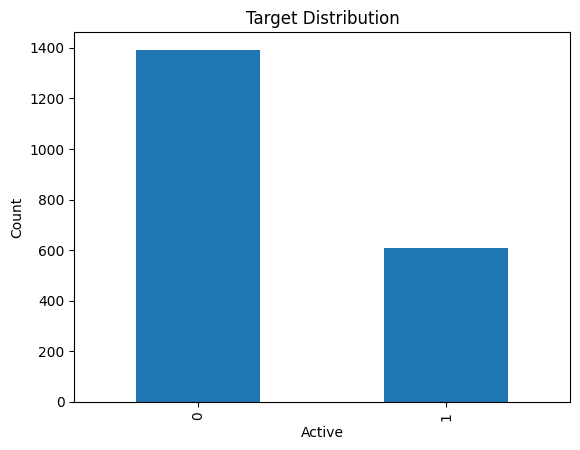

In [7]:
plt.Figure(figsize=(6,5))
df['active'].value_counts().plot(kind="bar")
plt.xlabel("Active")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.show()

In [8]:
def target(col):
    return df[col].value_counts(normalize=True)*100

target('active')

active
0    69.6
1    30.4
Name: proportion, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [10]:
X = df.drop(['compound_id','protein_id','active','binding_affinity'],axis=1)
y = df['active']

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
num_cols = X_train.select_dtypes(include=['float64','int64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

In [13]:
num_pipeline = Pipeline([
    ('num',SimpleImputer(strategy="median")),
    ('scale', StandardScaler())
])

In [14]:
cat_pipeline = Pipeline([
    ('cat',SimpleImputer(strategy="most_frequent")),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

In [15]:
preprocessor = ColumnTransformer([
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])

In [16]:
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('smote',SMOTE(random_state=42)),
    ('model',RandomForestClassifier(n_estimators=20,max_depth=5,random_state=42))
])

In [17]:
try:
    pipeline.fit(X_train,y_train)
except:
    print("Error")

In [18]:
y_pred = pipeline.predict(X_test)

In [19]:
check = accuracy_score(y_test,y_pred)

In [20]:
check

0.885

In [21]:
cm = confusion_matrix(y_test,y_pred)

In [22]:
cm

array([[235,  32],
       [ 14, 119]])

In [23]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91       267
           1       0.79      0.89      0.84       133

    accuracy                           0.89       400
   macro avg       0.87      0.89      0.87       400
weighted avg       0.89      0.89      0.89       400



In [24]:
import pickle
pickle.dump(pipeline,open("drug_discovery_model.pkl","wb"))
print("✅ Succesfully Exported")

✅ Succesfully Exported
